# 🔍 Data Preparation 

## ⚙️ Library Imports and Setup

In [83]:
from pymongo import MongoClient

from sklearn.preprocessing import LabelEncoder
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
import numpy as np



## 🔗 Database Connection and Data Retrieval

In [84]:
# 1. Connection and Data Retrieval
load_dotenv()

# Use environment variables
client = MongoClient(os.getenv('MONGODB_URI'))
db = client[os.getenv('MONGODB_DATABASE')]

## 🔄 Preparing Dataset: NPM Placement Data and AOI Defect Integration

In [85]:
def get_prepared_data():
    # --- 1. EXTRACTION NPM VF (Placement) ---
    npm_rows = []
    for doc in db["NPM-VF"].find({}):
        machine_name = doc.get("MachineName")
        last_update = doc.get("LastUpdate")
        
        # Secure time management
        if hasattr(last_update, 'hour'): # If it is a datetime object
            hour_val = last_update.hour
        elif isinstance(last_update, dict): # If it’s a dict
            hour_val = pd.to_datetime(last_update.get("$date")).hour
        else:
            hour_val = 0
        for exec_item in doc.get('Executions', []):
            board = exec_item.get('BoardNpm_VF', {})
            nzl_map = {n['nzlReferenceLink']: n['name'] for n in board.get('nzls', [])}
            mat_map = {m['materialReferenceLink']: m for m in board.get('materials', [])}
            
            for pattern in board.get("patterns", []):
                barcode = pattern.get("patternBarcode")
                for comp in pattern.get("components", []):
                    mat_info = mat_map.get(comp.get("materialReferenceLink"), {})
                    
                    npm_rows.append({
                        "barcode": barcode,
                        "designator": comp.get("Designator"), # Ex: C852
                        "nozzle": nzl_map.get(comp.get("nzlReferenceLink")),
                        "feeder": mat_info.get("feederID"),
                        "material_part": mat_info.get("part"),
                        "x": float(comp.get("coordinate", {}).get("coordinateX", 0)),
                        "y": float(comp.get("coordinate", {}).get("coordinateY", 0)),
                        "machine": machine_name,
                        "hour": hour_val
                    })
    df_npm = pd.DataFrame(npm_rows)
    #print(df_npm['barcode'].nunique())
    # --- 2. EXTRACTION AOI (Defects by Designator) ---
    aoi_defect_rows = []
    for doc in db["Verification-station"].find({}):
        for exec_item in doc.get('Executions', []):
            body = exec_item.get('boardVerification', {}).get('MessageBody', {})
            for unit in body.get('InspectedUnits', []):
                barcode_aoi = unit.get("UnitIdentifier")
                
                for inspection in unit.get("Inspections", []):
                    for defect in inspection.get("DefectsFound", []):
                        comp_of_interest = defect.get("ComponentOfInterest", {})
                        raw_des = comp_of_interest.get("ReferenceDesignator")
                        
                        # Nettoyage : "C852_Pin-1" -> "C852"
                        clean_des = raw_des.split('_')[0] if raw_des else None
                        
                        aoi_defect_rows.append({
                            "barcode": barcode_aoi,
                            "designator": clean_des,
                            "defect_code": defect.get("DefectCode"), # The new feature
                            "target_result": "Failed" # If present in this list, it is a failure
                        })
    
    df_aoi = pd.DataFrame(aoi_defect_rows)
    #print(df_aoi['barcode'].nunique())
    
    # --- 3. FUSION (MERGE) ---
    # We link the placement and the defect on the couple Barcode + Designator
    df_final = pd.merge(df_npm, df_aoi, on=["barcode", "designator"], how="left")

    # Filling of components WITHOUT defects
    df_final["target_result"] = df_final["target_result"].fillna("Pass")
    df_final["defect_code"] = df_final["defect_code"].fillna("None")
    
    return df_final

df_final = get_prepared_data()

ServerSelectionTimeoutError: localhost:27017: [WinError 10061] No connection could be made because the target machine actively refused it (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms), Timeout: 30s, Topology Description: <TopologyDescription id: 69d402502331915bfddae5f1, topology_type: Unknown, servers: [<ServerDescription ('localhost', 27017) server_type: Unknown, rtt: None, error=AutoReconnect('localhost:27017: [WinError 10061] No connection could be made because the target machine actively refused it (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms)')>]>

In [ ]:
print(f"Database ready : {df_final.shape[0]} lines.")

display(df_final.head(10))

Database ready : 2732338 lines.


,barcode,designator,nozzle,feeder,material_part,x,y,machine,hour,defect_code,target_result
0,CE65AK9P5A08002428325482,L850,NZ002,FA0299503000001,35650430,206.374,140.254,Npm VF,10,None,Pass
1,CE65AK9P5A08002428325482,C121,NZ002,FE0071AA1080085,35770496,200.090,62.270,Npm VF,10,None,Pass
2,CE65AK9P5A08002428325482,C120,NZ002,FE0071AA1080085,35770496,157.333,60.587,Npm VF,10,None,Pass
3,CE65AK9P5A08002428325482,C852,NZ002,FE0071AA1080084,35770497,182.656,143.533,Npm VF,10,None,Pass
4,CE65AK9P5A08002428428195,L850,NZ002,FA0299503000001,35650430,23.696,42.056,Npm VF,11,None,Pass
5,CE65AK9P5A08002428428195,C121,NZ002,FE0071AA1080085,35770496,29.932,120.178,Npm VF,11,None,Pass
6,CE65AK9P5A08002428428195,C120,NZ002,FE0071AA1080085,35770496,72.712,121.958,Npm VF,11,None,Pass
7,CE65AK9P5A08002428428195,C852,NZ002,FE0071AA1080084,35770497,47.344,38.977,Npm VF,11,None,Pass
8,CE65AK9P5A08002428428194,L850,NZ002,FA0299503000001,35650430,206.374,140.254,Npm VF,11,None,Pass
9,CE65AK9P5A08002428428194,C121,NZ002,FE0071AA1080085,35770496,200.090,62.270,Npm VF,11,None,Pass


In [ ]:
unique_boards = df_final['barcode'].nunique()
print(f"Dataset contains {unique_boards} unique board identifiers.")

Dataset contains 651851 unique board identifiers.


## ⚙️ Data Quality Check: Duplicate Detection

In [ ]:
# Count the number of exactly identical lines
nb_doublons = df_final.duplicated().sum()
print(f"Number of 100% identical lines : {nb_doublons}")

# Count if the same barcode appears several times (very common)
nb_barcode_doublons = df_final.duplicated(subset=['barcode']).sum()
print(f"Number of barcodes appearing more than once : {nb_barcode_doublons}")

Number of 100% identical lines : 118616
Number of barcodes appearing more than once : 2080486


## ⚙️ Data Cleaning: Drop Duplicate Entries

In [ ]:
initial_shape = df_final.shape[0]
df_final = df_final.drop_duplicates()
final_shape = df_final.shape[0]

print(f"Lines removed: {initial_shape - final_shape}")

Lines removed: 118616


## 🧹 Data Quality Check: Null Values

In [ ]:
# Display the number of null values per column
print("--- Analysis of missing values (Nulls) ---")
print(df_final.isnull().sum())

--- Analysis of missing values (Nulls) ---
barcode          264
designator         0
nozzle            12
feeder            12
material_part     12
x                  0
y                  0
machine            0
hour               0
defect_code        0
target_result      0
dtype: int64


## ⚙️ Data Cleaning: Drop and Impute Null Values

In [ ]:
df_final = df_final.dropna(subset=['material_part', 'nozzle', 'feeder'])

df_final['barcode'] = df_final['barcode'].fillna("UNKNOWN_BARCODE")

print(f"New line count: {len(df_final)}")

New line count: 2613710


In [ ]:
# Configuration du style
sns.set_theme(style="whitegrid")

## 🔍 Distribution of Pass vs Fail Results

C:\Users\PC-B4C-SYRINE\AppData\Local\Temp\ipykernel_27288\3287037581.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='target_result', palette={'Pass': 'green', 'Failed': 'red'})


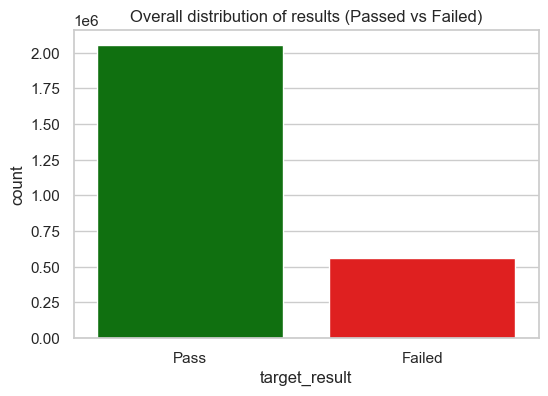

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_final, x='target_result', palette={'Pass': 'green', 'Failed': 'red'})
plt.title("Overall distribution of results (Passed vs Failed)")
plt.show()

## 🛑 Inspecting Failed Components

In [ ]:
df_errors = df_final[(df_final['target_result'] == 'Failed') ]
if not df_errors.empty:
    print("--- LIST OF DEFECTS FOUND ---")
    # We display the most important columns to understand the breakdown
    display(df_errors)
else:
    print("⚠️ Still no 'Failed' after merge. Checks if the dates of the two collections match (ex: August AOI vs October NPM).")

--- LIST OF DEFECTS FOUND ---


,barcode,designator,nozzle,feeder,material_part,x,y,machine,hour,defect_code,target_result
40,CE65AK9P5A08002428833969,L850,NZ002,FA0299503000001,35650430,23.696,42.056,Npm VF,11,Pseudofehler,Failed
78,CE65AK9P5A08002428833923,C120,NZ001,FE0071AA1080085,35770496,72.712,121.958,Npm VF,11,Pseudofehler,Failed
92,CE65AK9P5A08002428833840,L850,NZ003,FA0299503000001,35650430,206.374,140.254,Npm VF,11,Pseudofehler,Failed
102,CE65AK9P5A08002428833701,C120,NZ003,FE0071AA1080085,35770496,72.712,121.958,Npm VF,11,Pseudofehler,Failed
116,CE65AK9P5A08002428832167,L850,NZ003,FA0299503000001,35650430,23.696,42.056,Npm VF,12,Pseudofehler,Failed
...,...,...,...,...,...,...,...,...,...,...,...
2732322,CE65AK9P5A12002606102050,L850,NZ002,FA0299509000001,35650430,23.646,42.181,Npm VF,8,Pseudofehler,Failed
2732327,CE65AK9P5A12002606102049,C121,NZ002,FE0071AA1080082,35770496,200.090,62.270,Npm VF,8,Pseudofehler,Failed
2732328,CE65AK9P5A12002606102049,C120,NZ002,FE0071AA1080082,35770496,157.333,60.617,Npm VF,8,Pseudofehler,Failed
2732331,CE65AK9P5A12002605801061,C121,NZ001,FE0071AA1080082,35770496,200.090,62.270,Npm VF,8,Pseudofehler,Failed


## 🧹 Correcting False Positives

In [ ]:
# Identify and correct false positives (Pseudofehler)
mask_pseudo = df_final['defect_code'] == 'Pseudofehler'
df_final.loc[mask_pseudo, 'target_result'] = 'Pass'

print(f"Correction completed: {mask_pseudo.sum()} lines 'Pseudofehler' changed from 1 to 0.")

Correction completed: 549169 lines 'Pseudofehler' changed from 1 to 0.


## 🔍 Distribution of Failures by Nozzle

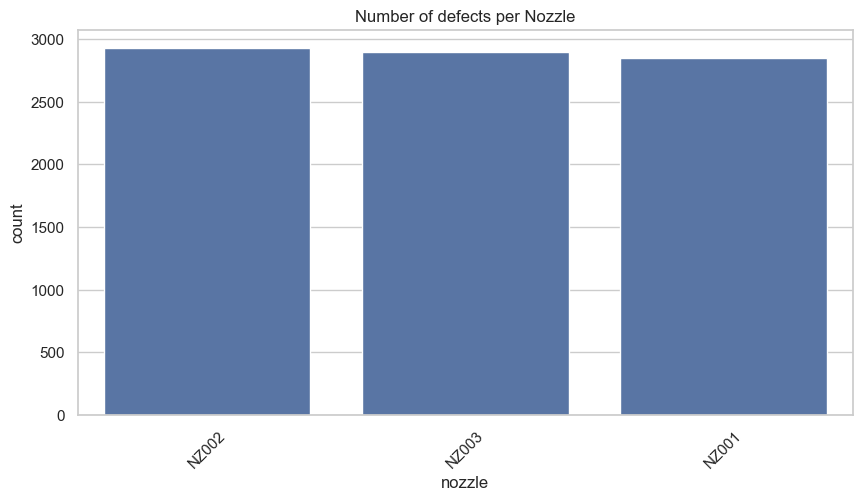

In [ ]:
# We filter to keep only the failures
df_only_failed = df_final[df_final['target_result'] == 'Failed']

if not df_only_failed.empty:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_only_failed, x='nozzle', order=df_only_failed['nozzle'].value_counts().index)
    plt.title("Number of defects per Nozzle")
    plt.xticks(rotation=45)
    plt.show()

## 🔍 Distribution of Failures by Feeder

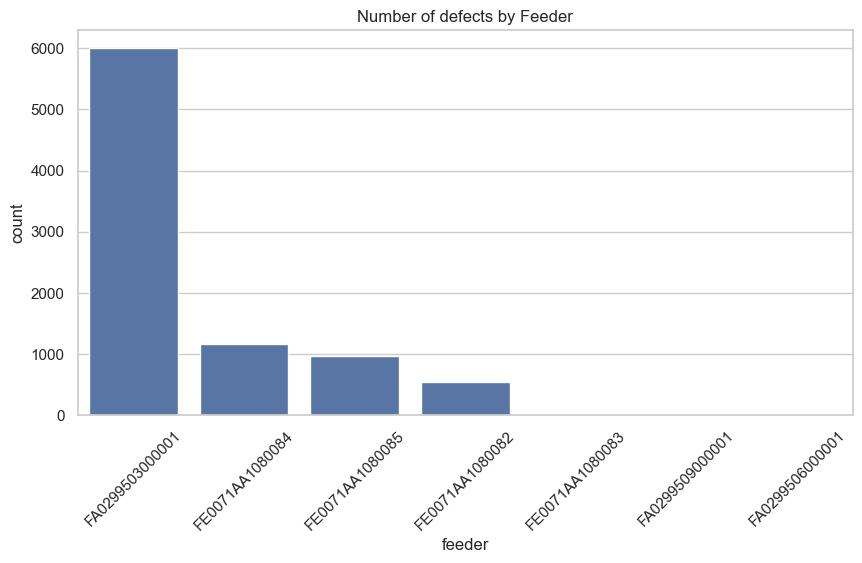

In [ ]:
# We filter to keep only the failures
df_only_failed = df_final[df_final['target_result'] == 'Failed']

if not df_only_failed.empty:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_only_failed, x='feeder', order=df_only_failed['feeder'].value_counts().index)
    plt.title("Number of defects by Feeder")
    plt.xticks(rotation=45)
    plt.show()

## 🔍 Scatterplot of Component Coordinates Highlighting Failures

C:\Users\PC-B4C-SYRINE\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


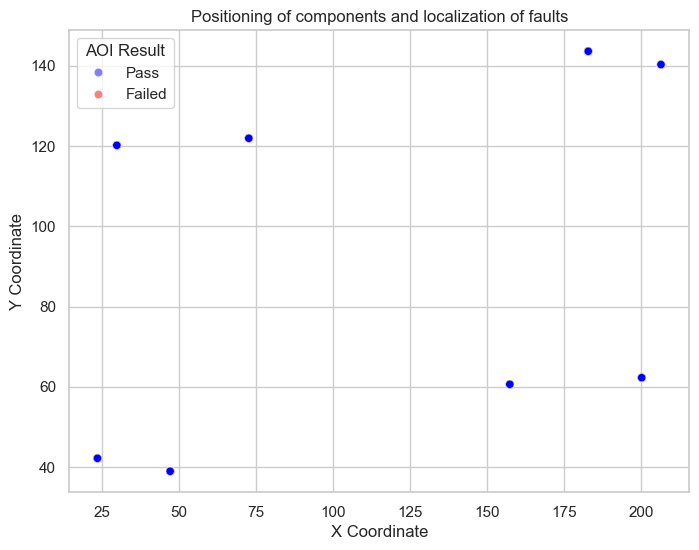

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_final, x='x', y='y', hue='target_result', 
                palette={'Pass': 'blue', 'Failed': 'red'}, alpha=0.5)
plt.title("Positioning of components and localization of faults")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend(title='AOI Result')
plt.show()

## ⏰ Distribution of Failures by Hour

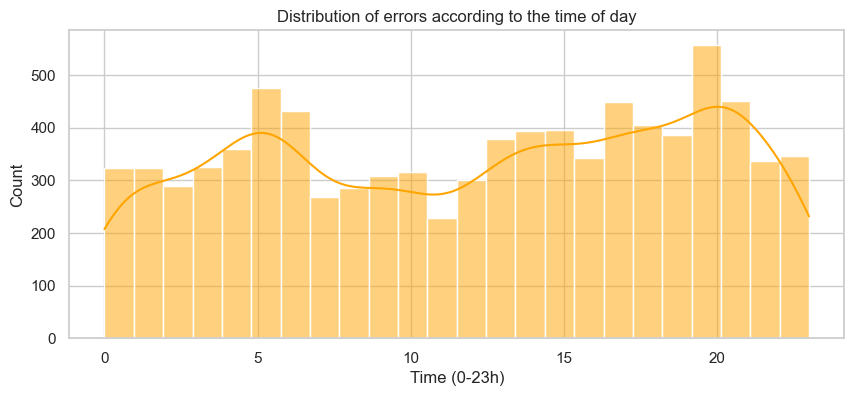

In [ ]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df_only_failed, x='hour', bins=24, kde=True, color='orange')
plt.title("Distribution of errors according to the time of day")
plt.xlabel("Time (0-23h)")
plt.show()

## ⚙️ Feature Engineering: Shift Assignment from Hour

In [ ]:
def assign_shift(hour):
    if 6 <= hour < 14:
        return 'Morning'
    elif 14 <= hour < 22:
        return 'Afternoon'
    else:
        return 'Night'

# Creation of the new column
df_final['shift'] = df_final['hour'].apply(assign_shift)

# Visual check
print("Distribution of components by Shift :")
print(df_final['shift'].value_counts())

Distribution of components by Shift :
shift
Afternoon    949880
Morning      931456
Night        732374
Name: count, dtype: int64


## 🔍 Distribution of Actual Failures Across Work Shifts

C:\Users\PC-B4C-SYRINE\AppData\Local\Temp\ipykernel_27288\2169736169.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_real_errors, x='shift', order=['Morning', 'Afternoon', 'Night'], palette='viridis')


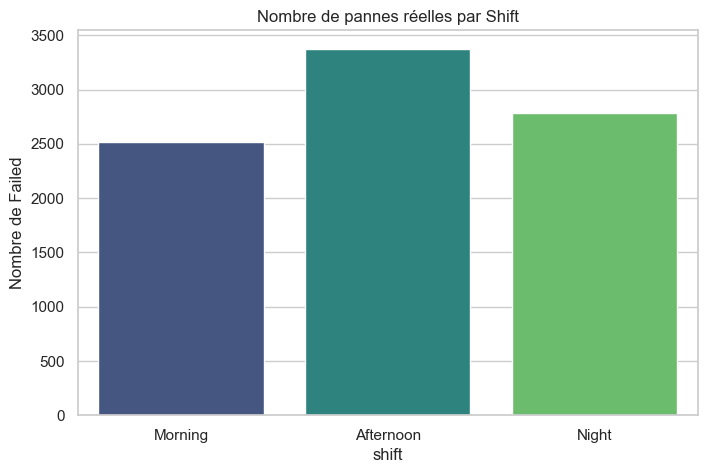

In [ ]:
# We filter to keep only the real failures
df_real_errors = df_final[df_final['target_result'] == 'Failed']

plt.figure(figsize=(8, 5))
sns.countplot(data=df_real_errors, x='shift', order=['Morning', 'Afternoon', 'Night'], palette='viridis')
plt.title("Nombre de pannes réelles par Shift")
plt.ylabel("Nombre de Failed")
plt.show()

## 🔍 Preserving Raw Data Before Encoding

In [ ]:
# Creation of the mirror copy before encoding
df_raw = df_final.copy()
print(f"Volume: {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.")

✅ Backup copy 'df_raw' created.
Volume: 2613710 rows and 12 columns.


## ⚙️ Feature Engineering: Euclidean & Polar Transformations

In [ ]:
# Euclidean distance (Distance from center 0.0)
df_raw['dist_center'] = np.sqrt(df_raw['x']**2 + df_raw['y']**2)

# Multiplication Interaction (To detect combined areas)
df_raw['xy_interaction'] = df_raw['x'] * df_raw['y']

# Polar Coordinates (The angle, very useful for rotating machines)
df_raw['angle'] = np.arctan2(df_raw['y'], df_raw['x'])

display(df_raw)

,barcode,designator,nozzle,feeder,material_part,x,y,machine,hour,defect_code,target_result,shift,dist_center,xy_interaction,angle
0,CE65AK9P5A08002428325482,L850,NZ002,FA0299503000001,35650430,206.374,140.254,Npm VF,10,None,Pass,Morning,249.522369,28944.778996,0.596910
1,CE65AK9P5A08002428325482,C121,NZ002,FE0071AA1080085,35770496,200.090,62.270,Npm VF,10,None,Pass,Morning,209.555627,12459.604300,0.301709
2,CE65AK9P5A08002428325482,C120,NZ002,FE0071AA1080085,35770496,157.333,60.587,Npm VF,10,None,Pass,Morning,168.595544,9532.334471,0.367585
3,CE65AK9P5A08002428325482,C852,NZ002,FE0071AA1080084,35770497,182.656,143.533,Npm VF,10,None,Pass,Morning,232.303544,26217.163648,0.666029
4,CE65AK9P5A08002428428195,L850,NZ002,FA0299503000001,35650430,23.696,42.056,Npm VF,11,None,Pass,Morning,48.272223,996.558976,1.057694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2732333,CE65AK9P5A12002605801061,C852,NZ001,FE0071AA1080083,35770497,182.766,143.613,Npm VF,8,None,Pass,Morning,232.439464,26247.573558,0.666007
2732334,CE65AK9P5A12002605801062,L850,NZ001,FA0299509000001,35650430,23.646,42.181,Npm VF,8,None,Pass,Morning,48.356696,997.411926,1.059863
2732335,CE65AK9P5A12002605801062,C121,NZ001,FE0071AA1080082,35770496,29.932,120.178,Npm VF,8,Pseudofehler,Pass,Morning,123.849410,3597.167896,1.326699
2732336,CE65AK9P5A12002605801062,C120,NZ001,FE0071AA1080082,35770496,72.712,121.928,Npm VF,8,None,Pass,Morning,141.962925,8865.628736,1.033064


## 🔢 Encoding Categorical Variables

In [ ]:
# List of columns to transform
categorical_cols = ['machine', 'nozzle', 'feeder', 'material_part', 'shift', 'designator']

# Creating a dictionary to keep track of encoders (useful for decoding later)
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    # On transforme le texte en nombres (ex : Matin -> 0, Après-midi -> 1...)
    df_raw[col] = le.fit_transform(df_raw[col].astype(str))
    encoders[col] = le

# Encodage de la cible (Target) : Pass -> 0, Failed -> 1
df_raw['target_result'] = df_raw['target_result'].map({'Pass': 0, 'Failed': 1})

print("✅ Encoding completed. Digital data preview:")
display(df_raw.head())

✅ Encoding completed. Digital data preview:


,barcode,designator,nozzle,feeder,material_part,x,y,machine,hour,defect_code,target_result,shift,dist_center,xy_interaction,angle
0,CE65AK9P5A08002428325482,3,1,0,1,206.374,140.254,0,10,None,0,1,249.522369,28944.778996,0.596910
1,CE65AK9P5A08002428325482,1,1,9,2,200.090,62.270,0,10,None,0,1,209.555627,12459.604300,0.301709
2,CE65AK9P5A08002428325482,0,1,9,2,157.333,60.587,0,10,None,0,1,168.595544,9532.334471,0.367585
3,CE65AK9P5A08002428325482,2,1,8,3,182.656,143.533,0,10,None,0,1,232.303544,26217.163648,0.666029
4,CE65AK9P5A08002428428195,3,1,0,1,23.696,42.056,0,11,None,0,1,48.272223,996.558976,1.057694


## 💾 Save Cleaned Dataset

In [ ]:
df_raw.to_parquet('../data/cleaned_data.parquet')
print("Cleaned dataset saved !")

Cleaned dataset saved !
